MODELYEAR                     1
MAKE                         39
MODEL                       663
VEHICLECLASS                 16
ENGINESIZE                   45
CYLINDERS                     7
TRANSMISSION                 22
FUELTYPE                      4
FUELCONSUMPTION_CITY        167
FUELCONSUMPTION_HWY         118
FUELCONSUMPTION_COMB        148
FUELCONSUMPTION_COMB_MPG     43
CO2EMISSIONS                159
dtype: int64
MODELYEAR                     int64
MAKE                         object
MODEL                        object
VEHICLECLASS                 object
ENGINESIZE                  float64
CYLINDERS                     int64
TRANSMISSION                 object
FUELTYPE                     object
FUELCONSUMPTION_CITY        float64
FUELCONSUMPTION_HWY         float64
FUELCONSUMPTION_COMB        float64
FUELCONSUMPTION_COMB_MPG      int64
CO2EMISSIONS                  int64
dtype: object


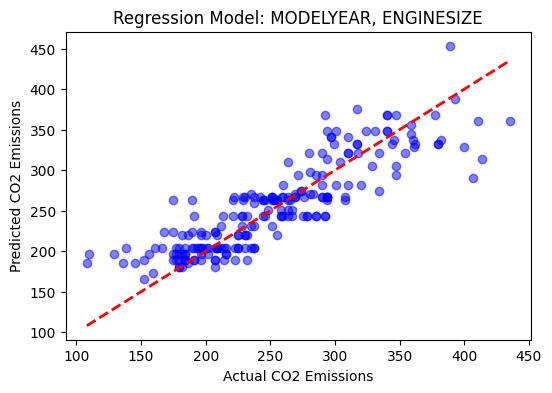

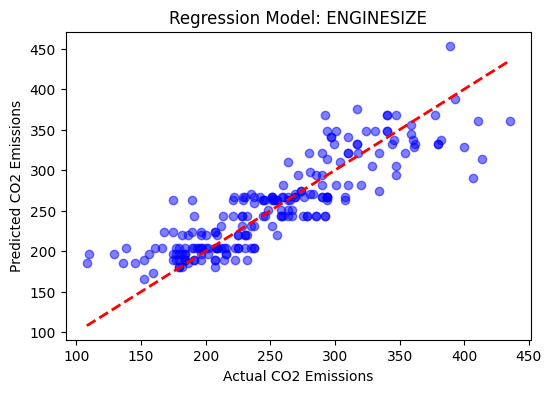

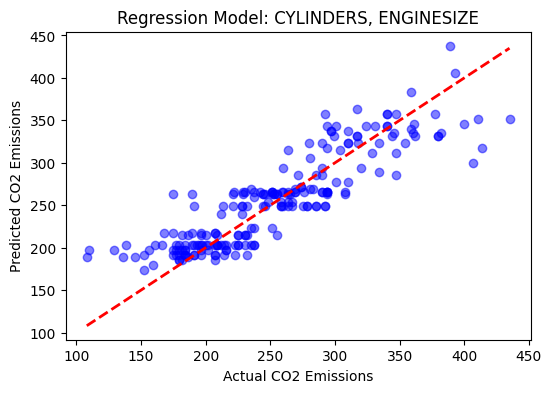

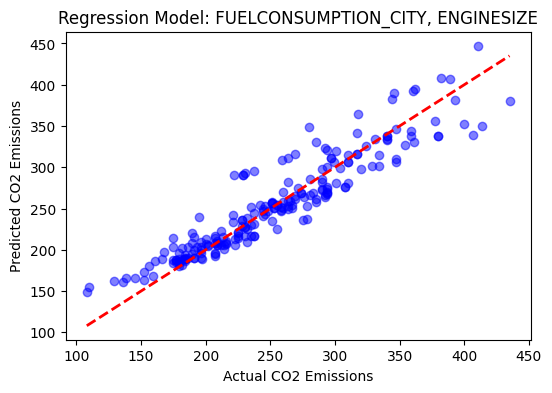

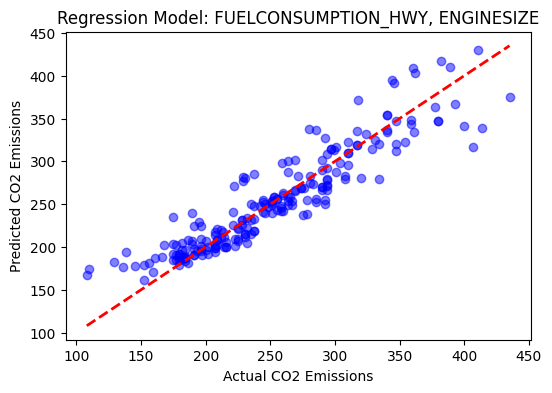

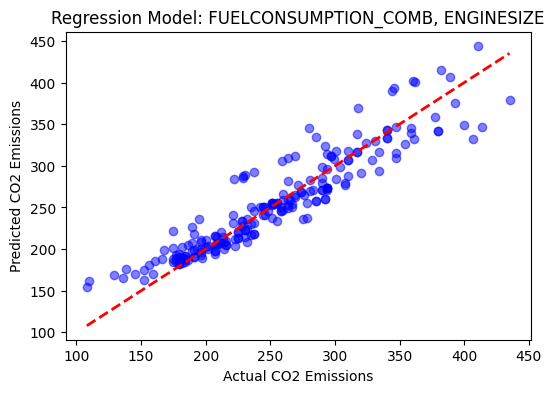

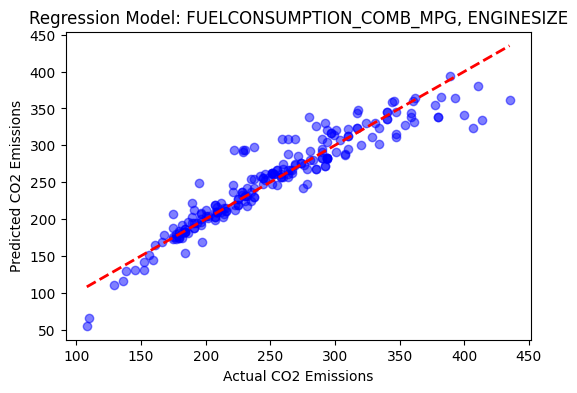

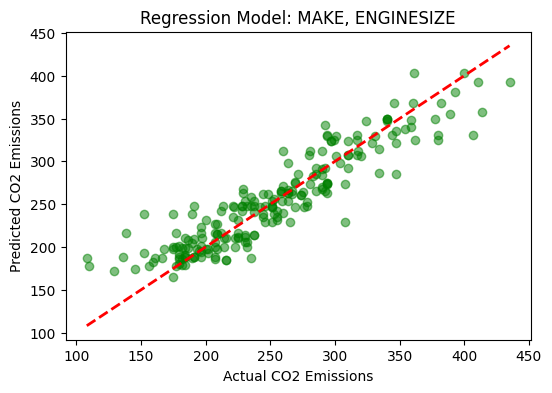

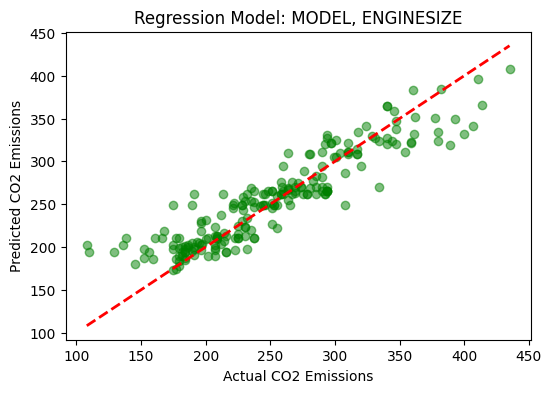

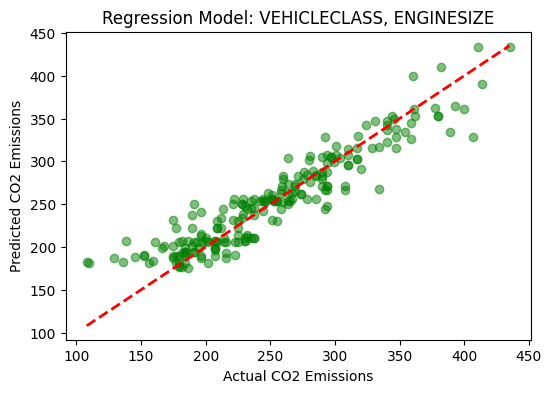

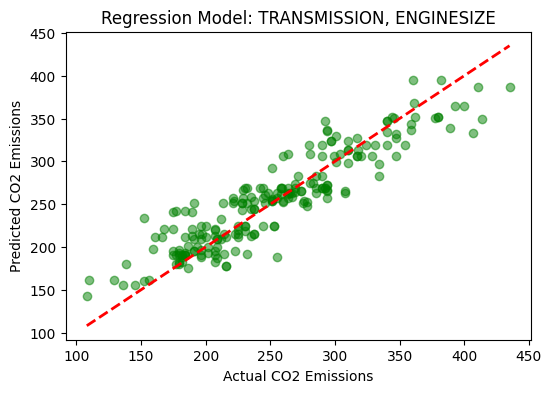

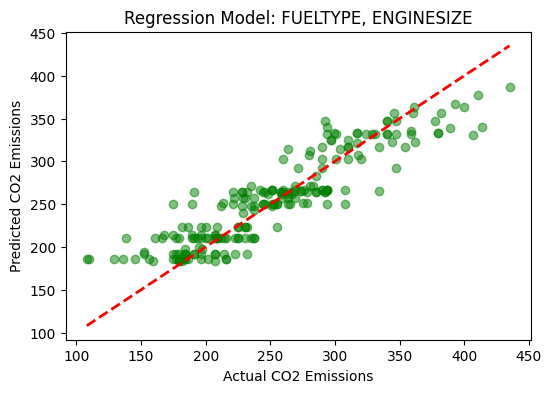

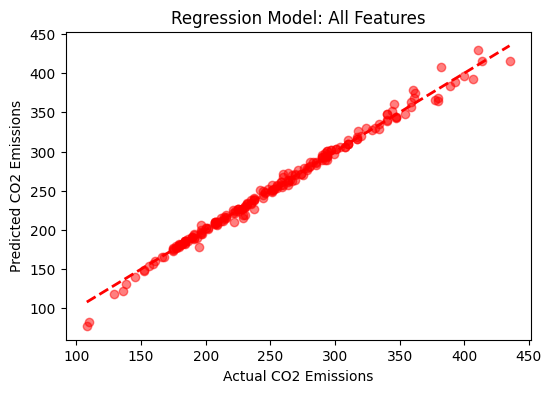

                                             Features        MAE         MSE  \
0                               MODELYEAR, ENGINESIZE  24.096974  986.066284   
1                                          ENGINESIZE  24.096974  986.066284   
2                               CYLINDERS, ENGINESIZE  23.755349  930.616659   
3                    FUELCONSUMPTION_CITY, ENGINESIZE  16.933559  531.558877   
4                     FUELCONSUMPTION_HWY, ENGINESIZE  18.085710  609.149074   
5                    FUELCONSUMPTION_COMB, ENGINESIZE  17.040358  543.690088   
6                FUELCONSUMPTION_COMB_MPG, ENGINESIZE  14.283523  465.863132   
7                                    MAKE, ENGINESIZE  19.558308  663.359354   
8                                   MODEL, ENGINESIZE  19.789489  713.926861   
9                            VEHICLECLASS, ENGINESIZE  17.563800  541.268903   
10                           TRANSMISSION, ENGINESIZE  20.257060  680.855352   
11                               FUELTYP

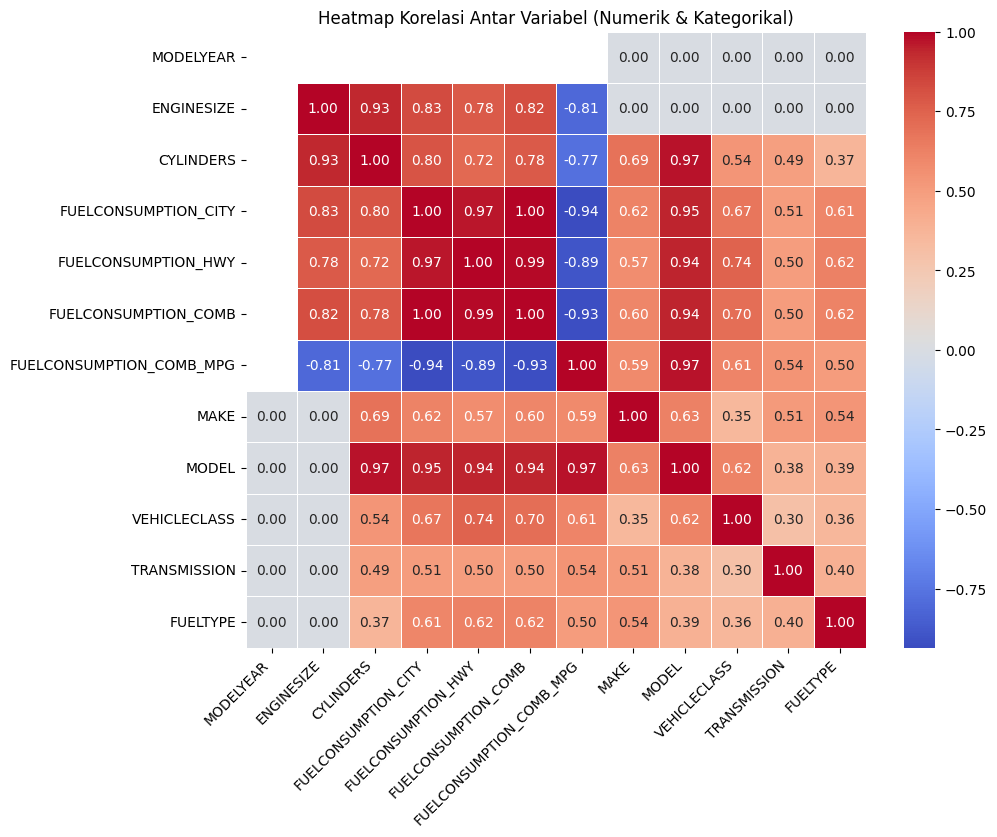

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_csv("FuelConsumptionCo2.csv")

# Check the number of unique values and data types before preprocessing
print(df.nunique())  # Check the number of unique values in each column
print(df.dtypes)  # Check the data types in each column

# Target variable
target = 'CO2EMISSIONS'

# List of numeric variables excluding CO2EMISSIONS
numerical_combinations = [
    ['MODELYEAR', 'ENGINESIZE'],
    ['ENGINESIZE'],
    ['CYLINDERS', 'ENGINESIZE'],
    ['FUELCONSUMPTION_CITY', 'ENGINESIZE'],
    ['FUELCONSUMPTION_HWY', 'ENGINESIZE'],
    ['FUELCONSUMPTION_COMB', 'ENGINESIZE'],
    ['FUELCONSUMPTION_COMB_MPG', 'ENGINESIZE']
]

# List of categorical variables with ENGINESIZE
categorical_combinations = [
    ['MAKE', 'ENGINESIZE'],
    ['MODEL', 'ENGINESIZE'],
    ['VEHICLECLASS', 'ENGINESIZE'],
    ['TRANSMISSION', 'ENGINESIZE'],
    ['FUELTYPE', 'ENGINESIZE']
]

# Add the “All Variables” category
all_features = ['ENGINESIZE', 'MODELYEAR', 'CYLINDERS', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB', 'FUELCONSUMPTION_COMB_MPG', 'MAKE', 'MODEL', 'VEHICLECLASS', 'TRANSMISSION', 'FUELTYPE']

# Save evaluation results
results = []
scaler = StandardScaler()
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Model Evaluation with Numerical Variables
for features in numerical_combinations:
    X = scaler.fit_transform(df[features])
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = Ridge(alpha=1.0)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        'Features': ', '.join(features),
        'MAE': mean_absolute_error(y_test, y_pred),
        'MSE': mean_squared_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAPE': np.mean(np.abs((y_test - y_pred) / y_test)) * 100,
        'R-squared': r2_score(y_test, y_pred)
    })

    # Regression visualization
    plt.figure(figsize=(6, 4))
    plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel("Actual CO2 Emissions")
    plt.ylabel("Predicted CO2 Emissions")
    plt.title(f"Regression Model: {', '.join(features)}")
    plt.show()

# Model Evaluation with Categorical Variables
for features in categorical_combinations:
    df[features] = df[features].astype(str)
    X = encoder.fit_transform(df[features])
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = Ridge(alpha=1.0)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        'Features': ', '.join(features),
        'MAE': mean_absolute_error(y_test, y_pred),
        'MSE': mean_squared_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAPE': np.mean(np.abs((y_test - y_pred) / y_test)) * 100,
        'R-squared': r2_score(y_test, y_pred)
    })

    # Regression visualization
    plt.figure(figsize=(6, 4))
    plt.scatter(y_test, y_pred, color='green', alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel("Actual CO2 Emissions")
    plt.ylabel("Predicted CO2 Emissions")
    plt.title(f"Regression Model: {', '.join(features)}")
    plt.show()

# Model Evaluation with All Variables
categorical_features = df.select_dtypes(exclude=['number']).columns.tolist()
numerical_features = [f for f in all_features if f not in categorical_features]

df[categorical_features] = df[categorical_features].astype(str)
X_categorical = encoder.fit_transform(df[categorical_features])
X_numerical = scaler.fit_transform(df[numerical_features])
X = np.hstack([X_categorical, X_numerical])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

results.append({
    'Features': ', '.join(all_features),
    'MAE': mean_absolute_error(y_test, y_pred),
    'MSE': mean_squared_error(y_test, y_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
    'MAPE': np.mean(np.abs((y_test - y_pred) / y_test)) * 100,
    'R-squared': r2_score(y_test, y_pred)
})

# Regression visualization for a model with all variables
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, color='red', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual CO2 Emissions")
plt.ylabel("Predicted CO2 Emissions")
plt.title("Regression Model: All Features")
plt.show()

# Displaying the evaluation results
results_df = pd.DataFrame(results)
print(results_df)

# Function to calculate Cramér's V (Category vs. Category)
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1)) / (n-1))
    rcorr = r - ((r-1)**2) / (n-1)
    kcorr = k - ((k-1)**2) / (n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Function for calculating the Correlation Ratio (Categorical vs. Numeric)
def correlation_ratio(categories, values):
    categories = categories.astype(str)
    category_means = values.groupby(categories).mean()
    overall_mean = values.mean()
    numerator = sum(values.groupby(categories).count() * (category_means - overall_mean) ** 2)
    denominator = sum((values - overall_mean) ** 2)
    return np.sqrt(numerator / denominator) if denominator != 0 else 0

# List all required variables
all_features = [
    'MODELYEAR', 'ENGINESIZE', 'CYLINDERS',
    'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY',
    'FUELCONSUMPTION_COMB', 'FUELCONSUMPTION_COMB_MPG',
    'MAKE', 'MODEL', 'VEHICLECLASS', 'TRANSMISSION', 'FUELTYPE'
]

# Separate numeric and categorical data
categorical_vars = ['MAKE', 'MODEL', 'VEHICLECLASS', 'TRANSMISSION', 'FUELTYPE']
numerical_vars = [col for col in all_features if col not in categorical_vars]

# Converting Categorical Variables to Label Encoding
label_encoders = {}
for col in categorical_vars:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))  # Ensure the data is a string before encoding
    label_encoders[col] = le

# Function to calculate Cramér's V (Category vs. Category)
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1)) / (n-1))
    rcorr = r - ((r-1)**2) / (n-1)
    kcorr = k - ((k-1)**2) / (n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Function for calculating the Correlation Ratio (Categorical vs. Numeric)
def correlation_ratio(categories, values):
    categories = categories.astype(str)
    try:
        category_means = values.groupby(categories).mean()
        overall_mean = values.mean()
        numerator = sum(values.groupby(categories).count() * (category_means - overall_mean) ** 2)
        denominator = sum((values - overall_mean) ** 2)
        return np.sqrt(numerator / denominator) if denominator != 0 else 0
    except:
        return 0  # Avoiding errors if there are categories with only one value

# Creating an empty DataFrame to store correlations
correlation_matrix = pd.DataFrame(index=all_features, columns=all_features)

# Calculate the numerical correlation (Pearson)
numerical_corr = df[numerical_vars].corr(method='pearson')

for col1 in numerical_vars:
    for col2 in numerical_vars:
        correlation_matrix.loc[col1, col2] = numerical_corr.loc[col1, col2]

# Calculate the correlation between two categorical variables (Cramér's V)
for col1 in categorical_vars:
    for col2 in categorical_vars:
        if col1 == col2:
            correlation_matrix.loc[col1, col2] = 1  # Self-correlation = 1
        else:
            correlation_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

# Calculate the correlation between categorical and numerical variables (Correlation Ratio)
for cat_col in categorical_vars:
    for num_col in numerical_vars:
        correlation_matrix.loc[cat_col, num_col] = correlation_ratio(df[cat_col], df[num_col])
        correlation_matrix.loc[num_col, cat_col] = correlation_matrix.loc[cat_col, num_col]  # Simetris

# Convert to float type for visualization
correlation_matrix = correlation_matrix.astype(float)

# Create a Combined Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Heatmap Korelasi Antar Variabel (Numerik & Kategorikal)")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()
